In [ ]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from sklearn.tree import DecisionTreeClassifier, plot_tree
from lifelines import KaplanMeierFitter
import torch
from swotted.utils import success_rate


project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    src_candidate = base / "src" / "trajectoryclusteringanalysis"
    if src_candidate.exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find project root containing src/trajectoryclusteringanalysis from {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Using local package from: {src_path}")

from trajectoryclusteringanalysis.tca import TCA

In [ ]:
df = pd.read_csv(project_root / "data" / "multidimensional_data.csv")
df

,PATIENT_ID,EVENT,TIME
0,1,Chirurgie,0
1,1,Chimiothérapie IV,1
2,1,Chimiothérapie IV,1
3,1,Chimiothérapie IV,2
4,1,Chimiothérapie IV,3
...,...,...,...
20430,1336,Chimiothérapie IV,2
20431,1336,Chimiothérapie IV,2
20432,1336,Chimiothérapie IV,3
20433,1336,Chimiothérapie IV,3


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
timed_event_structure = df.copy()

timed_event_structure['Event'] = label_encoder.fit_transform(timed_event_structure['EVENT'])
timed_event_structure.drop(columns=['EVENT'], inplace=True)
timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']
noms_events = label_encoder.classes_
timed_event_structure

,ID_PATIENT,Time,Event
0,1,0,2
1,1,1,0
2,1,1,0
3,1,2,0
4,1,3,0
...,...,...,...
20430,1336,2,0
20431,1336,2,0
20432,1336,3,0
20433,1336,3,0


In [ ]:
nunique = timed_event_structure['ID_PATIENT'].nunique()
print(f"Number of unique patients: {nunique}")

Number of unique patients: 1336


In [ ]:
# Get the set of all unique Event values
unique_events = timed_event_structure['Event'].unique()
all_events = set(unique_events)

# Find patients who have all occurrences of Event
patients_with_all_events = timed_event_structure.groupby('ID_PATIENT').filter(
    lambda group: set(group['Event']) == all_events
)['ID_PATIENT'].unique()

print(f"Patients with all occurrences of Event: {len(patients_with_all_events)}")
print(patients_with_all_events)

Patients with all occurrences of Event: 50
[   8   23   45   65   66  134  157  173  176  178  188  194  220  228
  242  275  312  343  361  390  428  466  469  472  478  537  544  546
  575  613  665  673  688  759  775  790  792  831  845  867  895  937
  943  969  984 1081 1126 1286 1293 1333]


In [ ]:
# Créer une instance de TCA pour l'analyse multidimensionnelle
tca = TCA(data=timed_event_structure,
              index_col='ID_PATIENT',
              time_col='Time', 
              event_col='Event',
              mode='multidimensional',
              )

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


In [ ]:
tca.analyzer.transform_time_event_structure_to_tensor()
print("Tensor shape:", tca.analyzer.get_tensor_shape())
tensor = tca.analyzer.get_tensor()

Tensor shape: torch.Size([1336, 4, 24])


In [ ]:
# Hyperparametres de la demo
rank = 3
reg_term_ns = 0.5
reg_term_s = 0.5
metric = 'Bernoulli'
learning_rate = 1e-3
n_epochs = 30  # 30 pour demo rapide, 100+ pour entrainement plus stable

Patient utilise pour la visualisation: 8


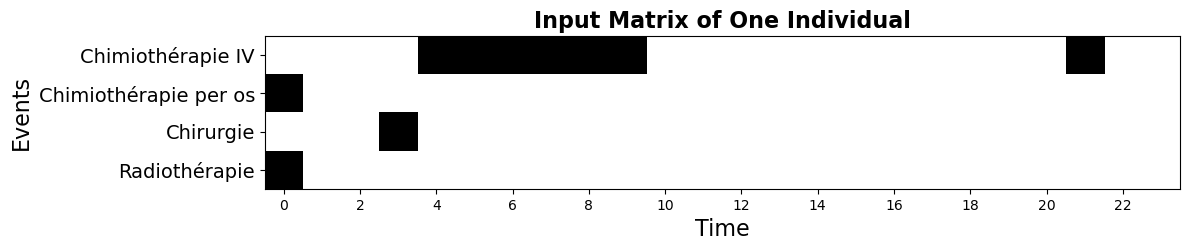

     PATIENT_ID                  EVENT  TIME
143           8  Chimiothérapie per os     0
144           8          Radiothérapie     0
145           8          Radiothérapie     0
146           8          Radiothérapie     0
147           8          Radiothérapie     0
148           8          Radiothérapie     0
149           8          Radiothérapie     0
150           8          Radiothérapie     0
151           8              Chirurgie     3
152           8              Chirurgie     3
153           8      Chimiothérapie IV     4
154           8      Chimiothérapie IV     5
155           8      Chimiothérapie IV     6
156           8      Chimiothérapie IV     6
157           8      Chimiothérapie IV     7
158           8      Chimiothérapie IV     7
159           8      Chimiothérapie IV     7
160           8      Chimiothérapie IV     8
161           8      Chimiothérapie IV     8
162           8      Chimiothérapie IV     9
163           8      Chimiothérapie IV     9
164       

In [ ]:
patient_index = int(patients_with_all_events[0])
print(f"Patient utilise pour la visualisation: {patient_index}")

plot_input_matrix(tensor, id=patient_index, labels=noms_events)

print(df[df['PATIENT_ID'] == 8])

Rien au mois 10, alors qu'il y a une chimiothérapie IV, et "déplacé" au mois 21

Patient utilise pour la visualisation: 23


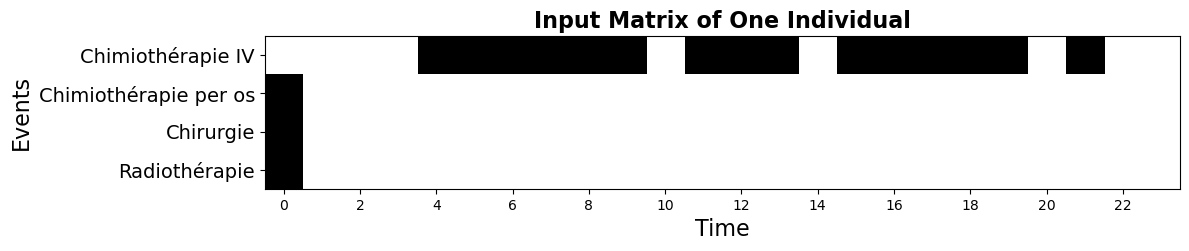

     PATIENT_ID                  EVENT  TIME
561          23              Chirurgie     0
562          23  Chimiothérapie per os     0
563          23          Radiothérapie     0
564          23          Radiothérapie     0
565          23          Radiothérapie     0
566          23          Radiothérapie     0
567          23      Chimiothérapie IV     4
568          23      Chimiothérapie IV     5
569          23      Chimiothérapie IV     5
570          23      Chimiothérapie IV     6
571          23      Chimiothérapie IV     7
572          23      Chimiothérapie IV     7
573          23      Chimiothérapie IV     8
574          23      Chimiothérapie IV     8
575          23      Chimiothérapie IV     9
576          23      Chimiothérapie IV    10
577          23      Chimiothérapie IV    13
578          23      Chimiothérapie IV    13
579          23      Chimiothérapie IV    14
580          23      Chimiothérapie IV    15
581          23      Chimiothérapie IV    17
582       

In [ ]:
patient_index = int(patients_with_all_events[1])
print(f"Patient utilise pour la visualisation: {patient_index}")

plot_input_matrix(tensor, id=patient_index, labels=noms_events)

print(df[df['PATIENT_ID'] == 23])

Pareil, le mois 10, 14 et 20 on a rien.

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 60     | n/a   | n/a  
--------------------------------------

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


Decomposed into 1336 pathways with rank 3 and time window length 5
FIT metric for the entire dataset: 0.0741
success_rate :0.012143991968069257


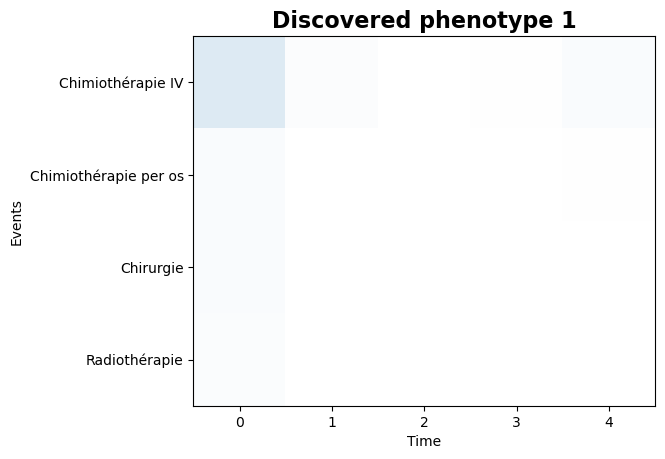

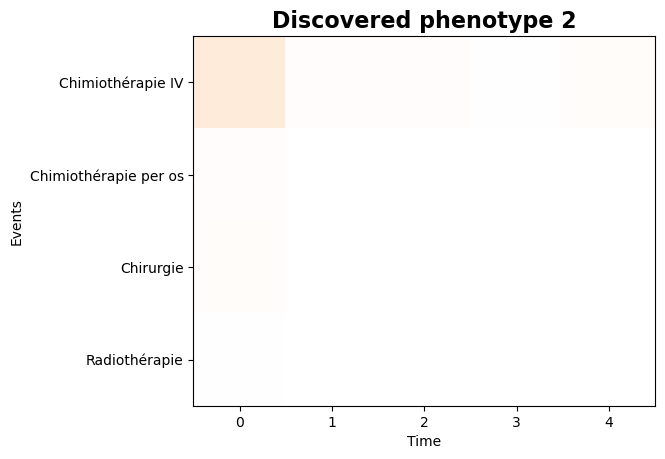

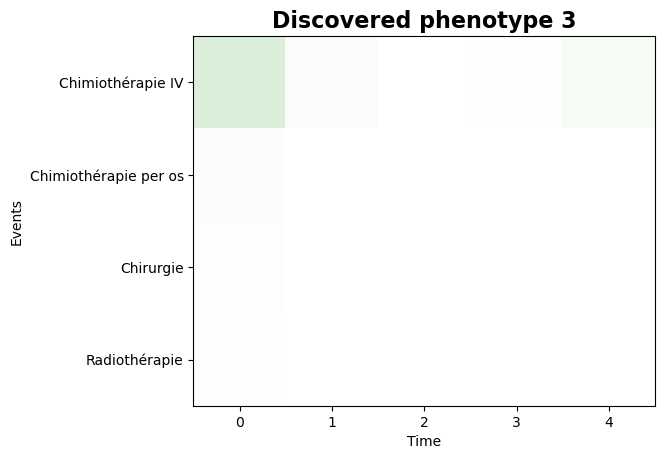

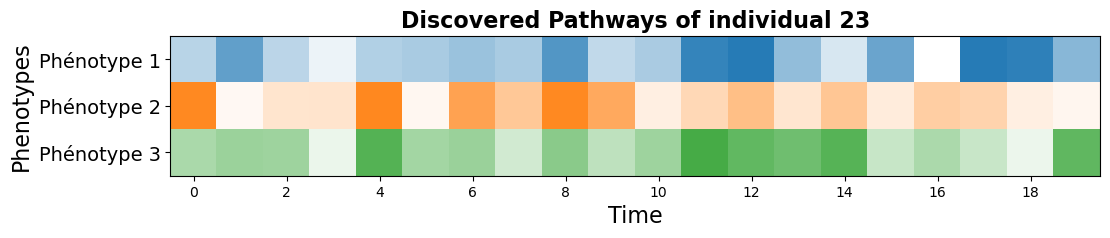

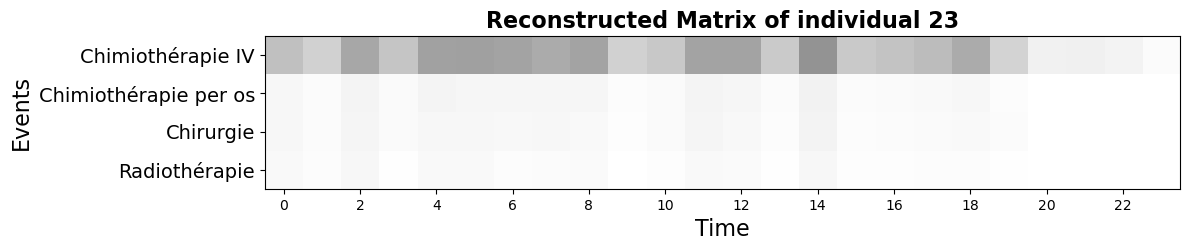

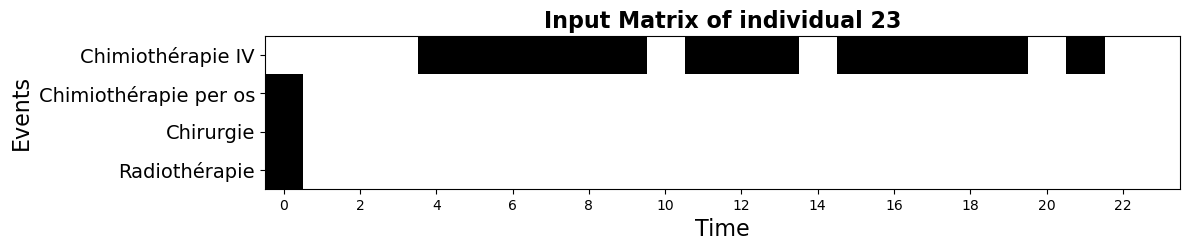

In [ ]:
tca.analyzer.fit_swotted_decomposition(
        tensor=tensor,
        rank=rank,
        time_window_length=twl,
        reg_term_ns=reg_term_ns,
        reg_term_s=reg_term_s,
        metric=metric,
        learning_rate=learning_rate,
        n_epochs=n_epochs
    )

tca.analyzer.get_decomposition_results(labels=noms_events, id=patient_index)

In [ ]:
# Test de plusieurs tailles de fenêtres temporelles (TWL)

window_lengths_to_test = [2, 3, 4, 5]
results = []


for twl in window_lengths_to_test:
    print(f"\n--- Entraînement en cours avec time_window_length = {twl} ---")
    
    tca.analyzer.fit_swotted_decomposition(
        tensor=tensor,
        rank=rank,
        time_window_length=twl,
        reg_term_ns=reg_term_ns,
        reg_term_s=reg_term_s,
        metric=metric,
        learning_rate=learning_rate,
        n_epochs=n_epochs
    )
    
    analyzer = tca.analyzer
    Ph = analyzer.model.Ph.detach().clone()
    
    X_pred = []
    for p in range(analyzer.K):
        X_pred.append(analyzer.model.model.reconstruct(analyzer.W[p], Ph))
    X_pred = torch.stack(X_pred)
    
    fit_metric = 1 - (torch.norm(analyzer.X - X_pred) / torch.norm(analyzer.X))
    sr_metric = success_rate(analyzer.X, X_pred)
    
    sr_value = sr_metric.item() if hasattr(sr_metric, 'item') else sr_metric
    
    print(f"-> Fenêtre {twl} terminée | FIT: {fit_metric.item():.4f} | Success Rate: {sr_value:.4f}")
    
    results.append({
        'time_window_length': twl,
        'FIT_metric': fit_metric.item(),
        'Success_rate': sr_value
    })

df_results = pd.DataFrame(results)
print("\nRésumé global des performances :")
display(df_results)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 24     | n/a   | n/a  
--------------------------------------


--- Entraînement en cours avec time_window_length = 2 ---


c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 36     | n/a   | n/a  
---------------------------------------------------------------
36        Trainable params
0         Non-trainable params
36        Total params
0.000     Total estimated model params size (MB)
1        

...

-> Fenêtre 4 terminée | FIT: 0.0782 | Success Rate: 0.0180

--- Entraînement en cours avec time_window_length = 5 ---


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


-> Fenêtre 5 terminée | FIT: 0.0756 | Success Rate: 0.0140

Résumé global des performances :


,time_window_length,FIT_metric,Success_rate
0,2,0.080356,0.018185
1,3,0.078367,0.016978
2,4,0.078222,0.017965
3,5,0.075620,0.014034


Les scores Fit et Success rate sont négatifs quand on a 100 époques

In [ ]:
from sklearn.preprocessing import StandardScaler

ph_intensity = tca.analyzer.to_phenotype_intensity(scaler=StandardScaler())
print("Shape intensites:", ph_intensity.shape)
ph_intensity.head()

Shape intensites: (1336, 4)


,Phenotype_1,Phenotype_2,Phenotype_3,ID_PATIENT
0,-0.131401,1.419736,-0.424963,1
1,1.140515,-0.640693,-1.026389,2
2,-0.307138,-0.357742,-0.445401,3
3,-1.274043,0.239765,-0.254557,4
4,-0.261036,1.231893,-0.722345,5


INFO:root:Calculating distance matrix using metric: euclidean...
INFO:root:Time taken for computation: 0.01 seconds
INFO:root:Computing the linkage matrix using method: ward...
c:\Users\imen.miloudi\Documents\stage\TrajectoryClusteringAnalysis\src\trajectoryclusteringanalysis\unidimensional\clustering.py:238: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(condensed_distance_matrix, method=method, optimal_ordering=optimal_ordering)
INFO:root:Linkage matrix computed successfully


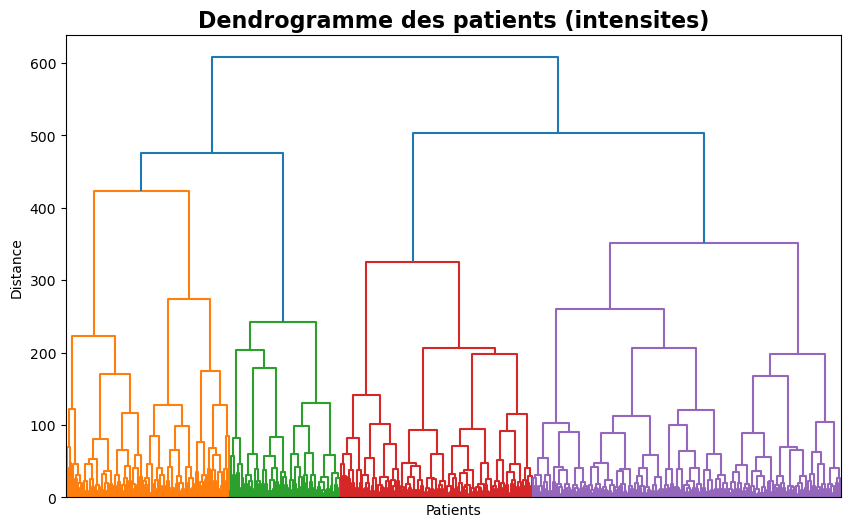

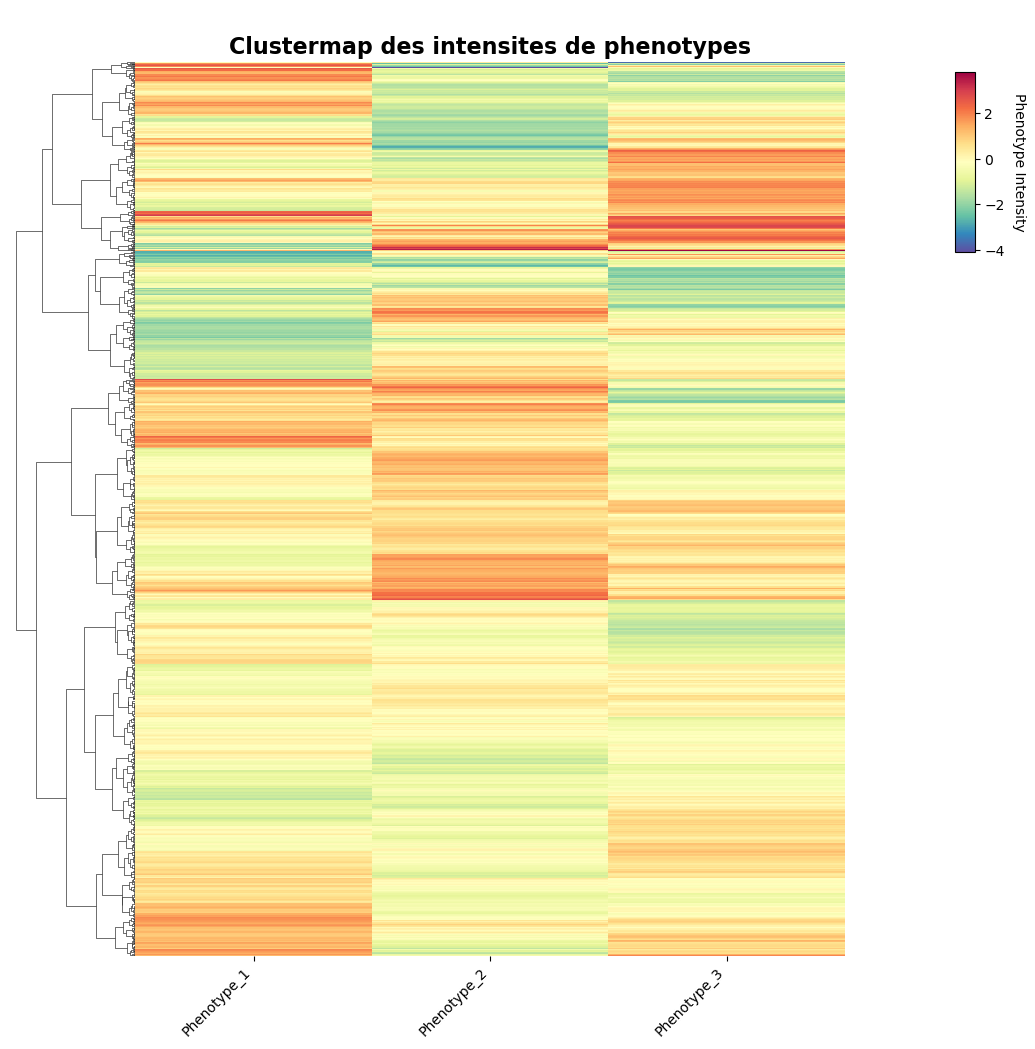

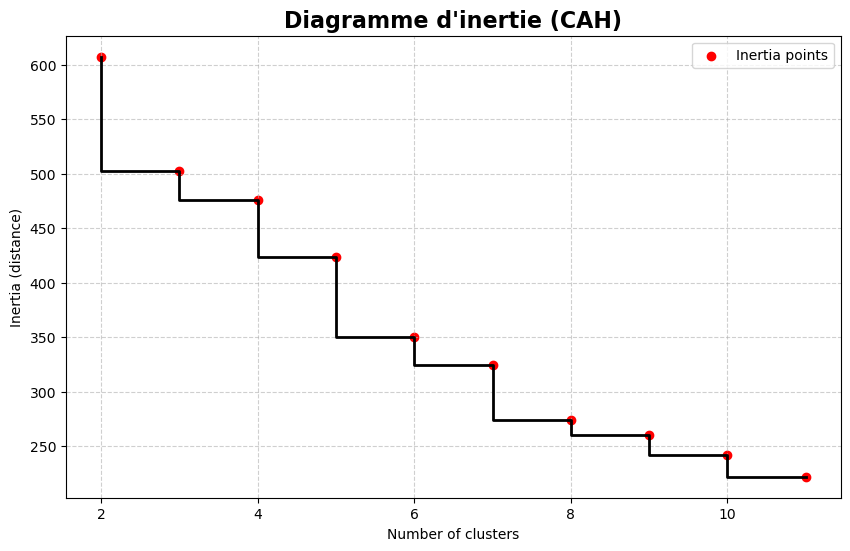

In [ ]:
distance_matrix = tca.compute_distance_matrix(data=ph_intensity, metric='euclidean')
linkage_matrix = tca.hierarchical_clustering(distance_matrix)

# Visualisations standard du package
tca.plot_dendrogram(linkage_matrix, title='Dendrogramme des patients (intensites)')
tca.plot_clustermap(ph_intensity, linkage_matrix, title='Clustermap des intensites de phenotypes')

tca.plot_inertia(linkage_matrix, title="Diagramme d'inertie (CAH)")

Choisir 4 clusters semble intéressant

Effectifs par cluster:
1    282
2    192
3    330
4    532
Name: count, dtype: int64


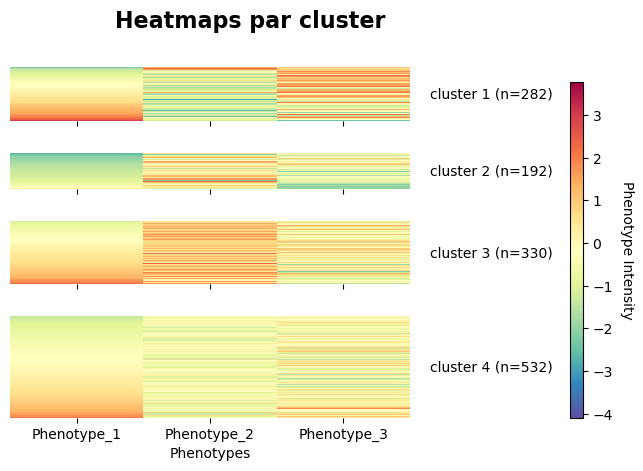

In [ ]:
clusters = tca.assign_clusters(linkage_matrix, num_clusters=4)
print("Effectifs par cluster:")
print(pd.Series(clusters).value_counts().sort_index())

tca.plot_cluster_heatmaps(ph_intensity, clusters, sorted=True, title='Heatmaps par cluster')